In [1]:
import pandas as pd
from scipy.optimize import minimize
import numpy as np

df = pd.read_csv("stocks.csv")


#Cleaning

canadian_stocks = ["SHOP", "CLS", "CRU"]
american_stocks = ["META", "AMZN", "NVDA"]

df.sort_values("Ticker")

df = df.sort_values(["Ticker", "MthCalDt"])

df = df.groupby(
    ["Ticker", "MthCalDt"],
    as_index=False
)["MthPrc"].mean()


df["Return"] = df.groupby("Ticker")["MthPrc"].pct_change()

df.head(8)

,Ticker,MthCalDt,MthPrc,Return
0,AMZN,2020-01-31,2008.72,NaN
1,AMZN,2020-02-28,1883.75,-0.062214
2,AMZN,2020-03-31,1949.72,0.035021
3,AMZN,2020-04-30,2474.00,0.268900
4,AMZN,2020-05-29,2442.37,-0.012785
5,AMZN,2020-06-30,2758.82,0.129567
6,AMZN,2020-07-31,3164.68,0.147114
7,AMZN,2020-08-31,3450.96,0.090461


In [37]:
returns = df.pivot(
    index="MthCalDt",
    columns="Ticker",
    values="Return"
)

returns.dropna()
returns.head()


Ticker,AMZN,CLS,CSU,META,NVDA,SHOP
MthCalDt,,,,,,
2020-01-31,NaN,NaN,NaN,NaN,NaN,NaN
2020-02-28,-0.062214,-0.300885,-0.082437,NaN,0.142283,-0.005047
2020-03-31,0.035021,-0.446203,-0.773438,NaN,-0.023957,-0.100106
2020-04-30,0.268900,0.780000,0.345517,NaN,0.108801,0.516538
2020-05-29,-0.012785,0.088283,-0.154280,NaN,0.214657,0.198501


In [38]:
mean_returns = returns.mean()
cov_matrix = returns.cov()

mean_returns.head()
cov_matrix.head()

Ticker,AMZN,CLS,CSU,META,NVDA,SHOP
Ticker,,,,,,
AMZN,0.021605,0.010617,0.004296,-0.186419,0.009983,0.022732
CLS,0.010617,0.036414,0.067932,-0.037710,0.009236,0.017558
CSU,0.004296,0.067932,8.337934,0.004433,-0.024268,-0.002543
META,-0.186419,-0.037710,0.004433,1.888021,-0.035025,-0.183826
NVDA,0.009983,0.009236,-0.024268,-0.035025,0.041223,0.014500


In [51]:
n = len(returns.columns)

def portfolio_variance(w):
    return w @ cov_matrix @ w

constraints = {
    "type": "eq",
    "fun": lambda w: np.sum(w) - 1
}

bounds = [(0, 1)] * n

initial_weights = np.ones(n) / n

result = minimize(
    portfolio_variance,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

weights = pd.Series(
    result.x,
    index=returns.columns
)

cleaned = (weights.round(2)*100).to_frame()
print(cleaned)

           0
Ticker      
AMZN    91.0
CLS      0.0
CSU      0.0
META     9.0
NVDA     0.0
SHOP     0.0


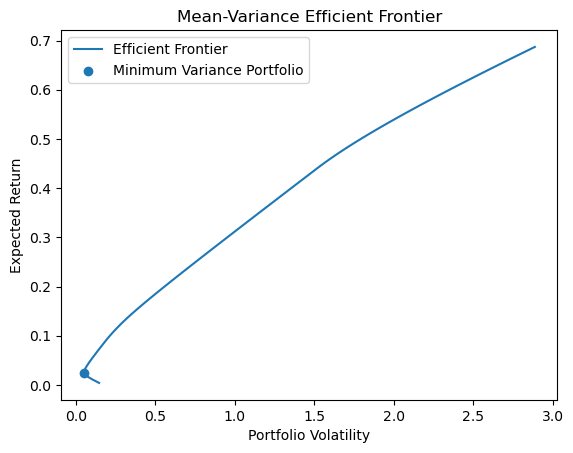

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

mean_returns = returns.mean()
cov_matrix = returns.cov()

n = len(returns.columns)

def portfolio_variance(w):
    return w @ cov_matrix @ w

initial_weights = np.ones(n) / n
bounds = [(0, 1)] * n

target_returns = np.linspace(
    mean_returns.min(),
    mean_returns.max(),
    100
)

frontier_returns = []
frontier_volatility = []

for target in target_returns:

    constraints = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1},
        {"type": "eq",
         "fun": lambda w, target=target:
             w @ mean_returns - target}
    ]

    result = minimize(
        portfolio_variance,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    if result.success:
        w = result.x

        frontier_returns.append(w @ mean_returns)
        frontier_volatility.append(
            np.sqrt(w @ cov_matrix @ w)
        )

# Find minimum variance portfolio
min_var_idx = np.argmin(frontier_volatility)

# Plot
plt.plot(
    frontier_volatility,
    frontier_returns,
    label="Efficient Frontier"
)

plt.scatter(
    frontier_volatility[min_var_idx],
    frontier_returns[min_var_idx],
    label="Minimum Variance Portfolio"
)

plt.xlabel("Portfolio Volatility")
plt.ylabel("Expected Return")
plt.title("Mean-Variance Efficient Frontier")
plt.legend()
plt.show()